In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set()

In [36]:
url = "https://www.fueleconomy.gov/feg/epadata/vehicles.csv"

df = pd.read_csv(url)

df.head(5)

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [26]:
df = df[(df['year'] >= 2008) & (df['year'] <= 2018)]

print("Shape:", df.shape)

Shape: (13339, 84)


In [27]:
print("Samples:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDuplicates:", df.duplicated().sum())

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

print("\nUnique Values:\n", df.nunique())

df['fuelType'].value_counts()

Samples: 13339
Columns: 84

Duplicates: 0

Data Types:
 barrels08     float64
barrelsA08    float64
charge120     float64
charge240     float64
city08          int64
               ...   
modifiedOn     object
startStop      object
phevCity        int64
phevHwy         int64
phevComb        int64
Length: 84, dtype: object

Missing Values:
 barrels08        0
barrelsA08       0
charge120        0
charge240        0
city08           0
              ... 
modifiedOn       0
startStop     5522
phevCity         0
phevHwy          0
phevComb         0
Length: 84, dtype: int64

Unique Values:
 barrels08     158
barrelsA08     63
charge120       1
charge240      27
city08         93
             ... 
modifiedOn    135
startStop       2
phevCity       33
phevHwy        39
phevComb       37
Length: 84, dtype: int64


fuelType
Regular                        6092
Premium                        5543
Gasoline or E85                1014
Diesel                          218
Electricity                     145
Premium or E85                  114
Midgrade                         90
Premium and Electricity          41
Regular Gas and Electricity      29
Premium Gas or Electricity       28
CNG                              11
Hydrogen                          9
Regular Gas or Electricity        3
Gasoline or natural gas           2
Name: count, dtype: int64

In [28]:
df.groupby('VClass')['city08'].mean()

VClass
Compact Cars                          22.968392
Large Cars                            20.464829
Midsize Cars                          23.128110
Midsize Station Wagons                20.628205
Minicompact Cars                      21.011419
Minivan - 2WD                         17.978873
Minivan - 4WD                         16.454545
Small Pickup Trucks 2WD               17.506173
Small Pickup Trucks 4WD               16.275281
Small Sport Utility Vehicle 2WD       22.250501
Small Sport Utility Vehicle 4WD       20.277696
Small Station Wagons                  24.234043
Special Purpose Vehicle 2WD           18.877358
Special Purpose Vehicle 4WD           15.318182
Sport Utility Vehicle - 2WD           18.085837
Sport Utility Vehicle - 4WD           16.284722
Standard Pickup Trucks 2WD            15.293103
Standard Pickup Trucks 4WD            14.571429
Standard Sport Utility Vehicle 2WD    16.443946
Standard Sport Utility Vehicle 4WD    18.118613
Subcompact Cars                  

In [29]:
df = df.drop_duplicates()

df.columns = df.columns.str.lower().str.strip()

df = df.fillna(method='ffill')

In [30]:
df = df.rename(columns={
    'city08': 'city_mpg',
    'highway08': 'highway_mpg',
    'fueltype': 'fuel_type',
    'vclass': 'vehicle_class',
    'smartway': 'smartway'
})

In [31]:
df['mpg_ratio'] = df['highway_mpg'] / df['city_mpg']

df = df.dropna()

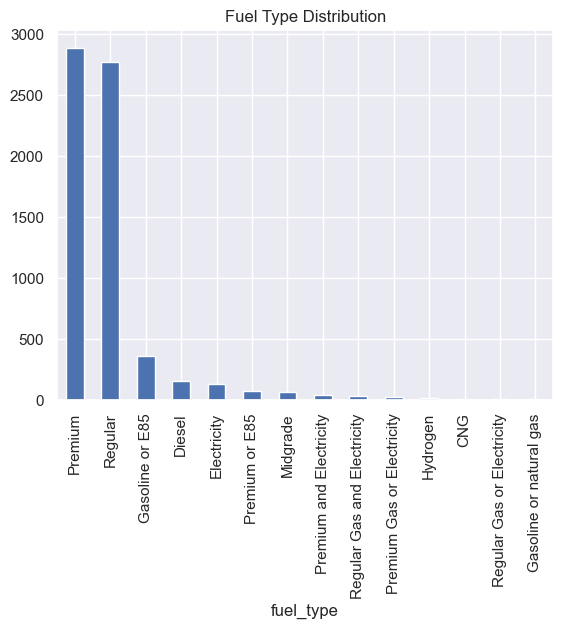

In [32]:
df['fuel_type'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.show()

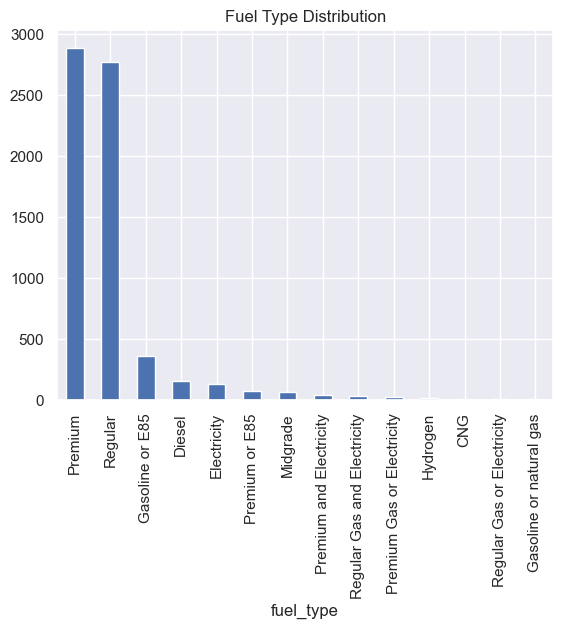

In [33]:
df['fuel_type'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.show()

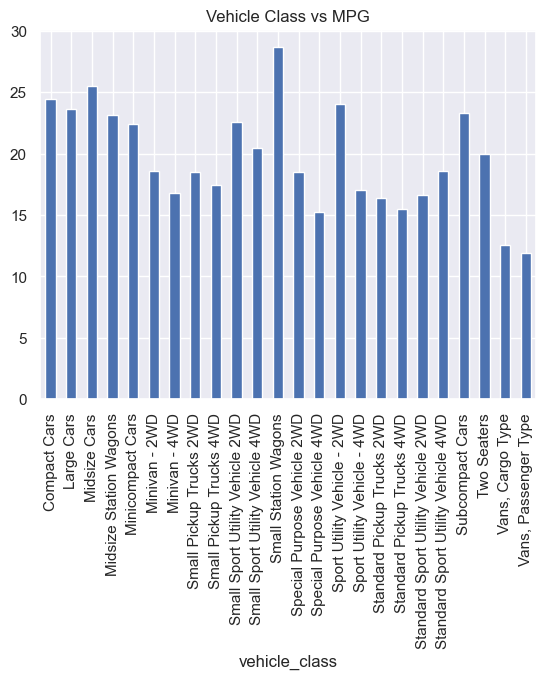

In [34]:
df.groupby('vehicle_class')['city_mpg'].mean().plot(kind='bar')
plt.title("Vehicle Class vs MPG")
plt.show()

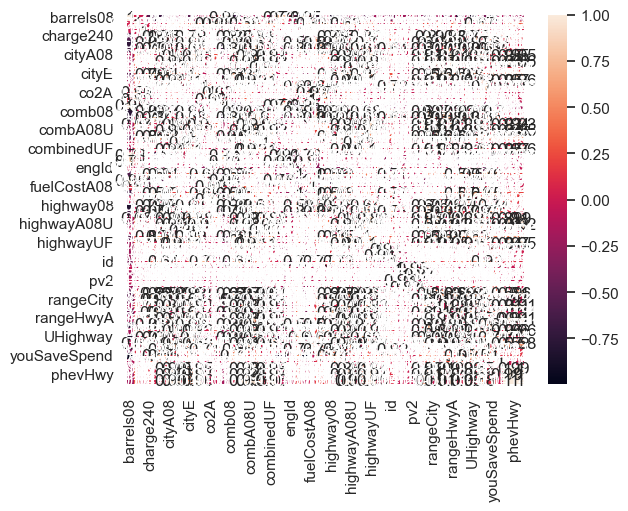

In [39]:
numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [45]:
df.columns = df.columns.str.lower().str.strip()

In [47]:
df = df.rename(columns={
    'city08': 'city_mpg',
    'highway08': 'highway_mpg',
    'fueltype': 'fuel_type',
    'vclass': 'vehicle_class'
})

In [48]:
print(df[['city_mpg','highway_mpg']].head())

   city_mpg  highway_mpg
0        19           25
1         9           14
2        23           33
3        10           12
4        17           23


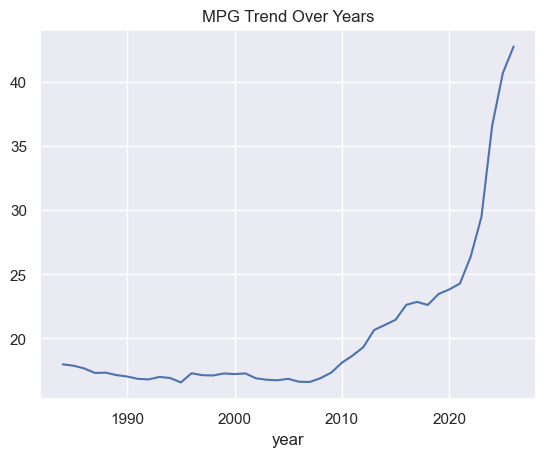

In [49]:
df.groupby('year')['city_mpg'].mean().plot()
plt.title("MPG Trend Over Years")
plt.show()


In [51]:
df['mpg_ratio'] = df['city_mpg'] / df['highway_mpg']

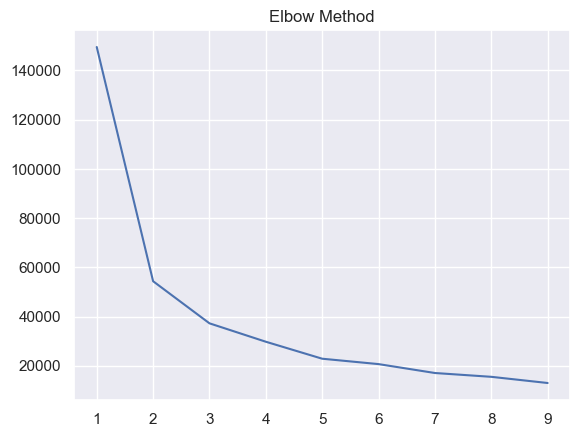

In [52]:
X = df[['city_mpg','highway_mpg','mpg_ratio']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia)
plt.title("Elbow Method")
plt.show()


In [55]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('cluster').mean(numeric_only=True)

,barrels08,barrelsa08,charge120,charge240,city_mpg,city08u,citya08,citya08u,citycd,citye,...,ucitya,uhighway,uhighwaya,year,yousavespend,charge240b,phevcity,phevhwy,phevcomb,mpg_ratio
cluster,,,,,,,,,,,,,,,,,,,,,
0,15.878830,0.226605,0.000000,0.004041,17.023275,6.959478,0.562540,0.386255,0.000168,0.071921,...,0.688688,33.847990,1.043231,2005.484977,-6297.340426,0.000000,0.027692,0.036460,0.030883,0.704260
1,0.192614,0.000000,0.000000,9.866562,97.689041,96.836704,0.000000,0.000000,0.000000,35.812534,...,0.000000,124.383729,0.000000,2022.945890,6679.452055,0.500822,0.000000,0.000000,0.000000,1.110495
2,14.396154,0.149941,0.000184,0.082284,20.975412,9.684918,1.809455,1.769227,0.001676,1.291692,...,2.566137,36.039208,1.367338,2003.454854,-4283.341011,0.000132,1.023609,1.026489,1.020442,0.826172


In [57]:
df.columns = df.columns.str.strip()

In [59]:
if 'smartway' in df.columns:
    y = le.fit_transform(df['smartway'])
else:
    print("Column 'smartway' not found")

Column 'smartway' not found


In [60]:
X = df[['city_mpg','highway_mpg','mpg_ratio']]

le = LabelEncoder()
y = le.fit_transform(df['fuel_type'])

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [64]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred1 = log_model.predict(X_test)

In [65]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

y_pred2 = tree_model.predict(X_test)

In [66]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Accuracy: 0.6425275827482447
Decision Tree Accuracy: 0.6643931795386159



Logistic Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00       261
           2       0.96      0.97      0.97       274
           4       0.00      0.00      0.00       273
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00        39
           9       0.54      0.26      0.35      3038
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        51
          12       0.00      0.00      0.00        31
          13       0.65      0.90      0.76      5936
          14       0.00      0.00      0.00        30
          15       0.00      0.00      0.00         1

    accuracy                           0.64      9970
   macro avg       0.14      0.14      0.14      9970
weighte

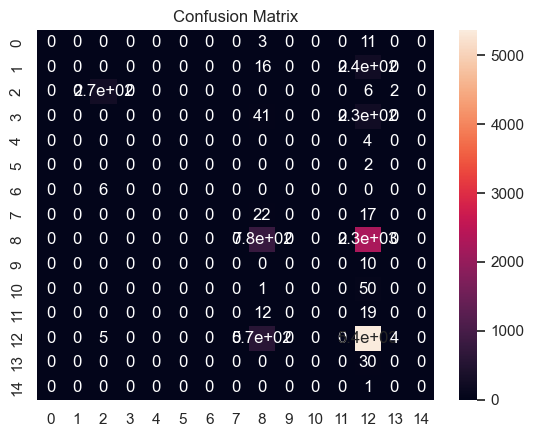

In [67]:
print("\nLogistic Report:\n", classification_report(y_test, y_pred1))

sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True)
plt.title("Confusion Matrix")
plt.show()

In [68]:
X = df[['highway_mpg','mpg_ratio']]
y = df['city_mpg']

reg = LinearRegression()
reg.fit(X,y)

print("R2 Score:", reg.score(X,y))

R2 Score: 0.9826186640537475


In [72]:
## Conclusion

- Alternative fuel usage increased  
- Clustering revealed efficiency segments  
- Logistic Regression was more stable than Decision Tree  
- Feature engineering improved performance  

SyntaxError: invalid syntax (3636991507.py, line 3)